Задача №1

Дз1
Для цепи Маркова, заданной стохастической матрицей переходов:
1.    нарисовать граф цепи;
2.    проверить выполнение критерия эргодичности;
3.    рассчитать предельные вероятности;
4.    записать предельную матрицу переходов;
5.    провести имитационное моделирование системы, соответствующей рассматриваемой цепи, для этого:
  · случайно выбрать начальное состояние;

  · случайно разыграть переход в новое состояние, учитывая распределение вероятностей перехода;

  · совершить 100 переходов;

  · подсчитать число вхождений в каждое из состояний системы;

  · повторить эксперимент 50 раз;

  · построить «графики» переключений состояний цепи (для наглядности соединяем дискретные точки) для 3 произвольных экспериментов;

  · составить таблицу для сравнения относительных частот наблюдений вхождения в каждое из состояний системы;
  
  · рассчитать выборочные средние и исправленные оценки среднеквадратичных отклонений указанных относительных частот.

3) Предельные вероятности
 [[0.17673746]
 [0.202437  ]
 [0.2099552 ]
 [0.21076379]
 [0.20010655]] 

4) Предельная матрица переходов
[[0.17673746 0.202437   0.2099552  0.21076379 0.20010655]
 [0.17673746 0.202437   0.2099552  0.21076379 0.20010655]
 [0.17673746 0.202437   0.2099552  0.21076379 0.20010655]
 [0.17673746 0.202437   0.2099552  0.21076379 0.20010655]
 [0.17673746 0.202437   0.2099552  0.21076379 0.20010655]] 

5)
Числа вхождений
 [[11. 26. 28. 14. 21.]
 [22. 19. 16. 29. 14.]
 [15. 20. 24. 25. 16.]
 [14. 21. 18. 22. 25.]
 [19. 20. 21. 14. 26.]
 [14. 24. 28. 21. 13.]
 [18. 15. 30. 21. 16.]
 [12. 19. 21. 22. 26.]
 [27. 15. 26. 11. 21.]
 [24. 22. 20. 19. 15.]
 [21. 20. 12. 25. 22.]
 [17. 27. 20. 19. 17.]
 [20. 25. 23. 18. 14.]
 [18. 19. 23. 18. 22.]
 [23. 27. 24. 12. 14.]
 [ 9. 20. 17. 34. 20.]
 [26. 14. 14. 27. 19.]
 [16. 27. 18. 13. 26.]
 [19. 25. 16. 21. 19.]
 [18. 20. 22. 25. 15.]
 [22. 19. 13. 17. 29.]
 [18. 24. 21. 18. 19.]
 [17. 13. 23. 24. 23.]
 [20. 17. 30. 18. 15.]
 [1

/tmp/ipykernel_2176/461440041.py:43: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "x" (-> marker='x'). The keyword argument will take precedence.
  ax.plot(range(100), S_j, 'x', ls='-', color=colors[k-1], label=f'№{k}', linewidth=1.0, marker=m_s[k-1])


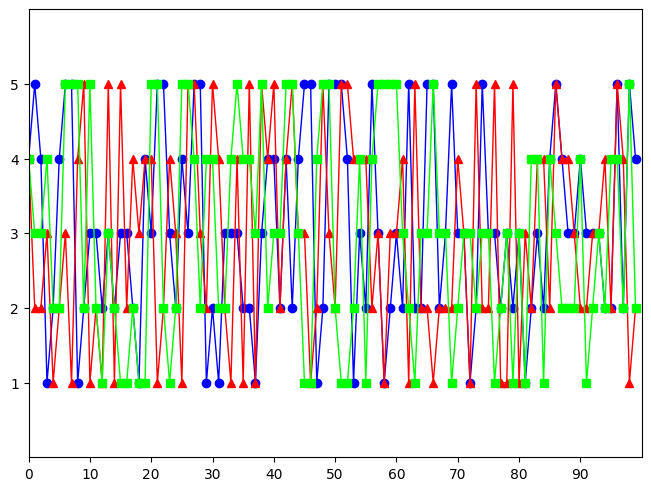

In [11]:
import numpy as np
import random as rd
import matplotlib.pyplot as plt
import matplotlib as mpl

P = np.array([[0.15, 0.19, 0.22, 0.19, 0.25],
              [0.20, 0.16, 0.21, 0.20, 0.23],
              [0.19, 0.23, 0.24, 0.21, 0.13],
              [0.17, 0.20, 0.20, 0.24, 0.19],
              [0.17, 0.23, 0.18, 0.21, 0.21]])

Pt = P.T - np.eye(5)
Pt[-1] = 1
Pn = np.linalg.solve( Pt, np.array([[0.], [0.], [0.], [0.], [1.]]) )
print("3) Предельные вероятности\n", Pn, "\n")

print("4) Предельная матрица переходов")
PnT = Pn.T
for i in range(2):
    PnT = np.append(PnT, PnT, axis=0)
PnT = np.append(PnT, Pn.T, axis=0)
print(PnT, "\n")

print("5)")
fig, ax = plt.subplots(layout='constrained')
cmap = mpl.colormaps['brg']
colors = cmap(np.linspace(0, 1, 3))

S_n = np.ones((50, 5))                  # Массивы вхождений экспериментов
k = 1
m_s = ['o', '^', 's']
for n in range(50):
    S_i = rd.randint(1, 5)        # Текущее состояние
    S = np.zeros(5)  # Массив чисел вхождений для n-нного эксперимента
    S_j = np.zeros(100)
    for j in range(100):
        S_i = rd.choices(range(1, 6), weights=P[S_i - 1], k=1)[0]
        S_j[j] = S_i
        S[S_i - 1] += 1
    S_n[n] = S

    if ((rd.randint(1, 50) <= 6) & (k <= 3)):
        ax.plot(range(100), S_j, 'x', ls='-', color=colors[k-1], label=f'№{k}', linewidth=1.0, marker=m_s[k-1])
        ax.set(xlim=(0, 100), xticks=np.arange(0, 100, 10),
               ylim=(0, 6), yticks=np.arange(1, 6))
        k+=1

print("Числа вхождений\n", S_n)
print("Таблица для сравнений\n", S_n[:]/100)
print("Предельные вероятности: ", *Pn.T)

print("Выборочные средние оценки: ", np.mean(S_n[:]/100, axis=0))

print("Исправленные оценки среднеквадратичных отклонений")
for i in range(5):
    print( ( (S_n[:, i]/100 - np.mean(S_n[:]/100, axis=0)[i]) ** 2).sum() / 99)

plt.show()


Задача №2
Для цепи Маркова, заданной стохастической матрицей переходов:
1. нарисовать граф цепи;
2. выделить классы существенных и несущественных состояний (вручную – обязательно; программным путём – дополнительное задание для желающих);
3. рассчитать предельные вероятности для классов существенных состояний;
4. не выполняя матричных операций с полной стохастической матрицей переходов, записать предельные вероятности в следующих случаях:
4.1. если достоверно известно, что система начинает работу в каком-то одном из состояний (для каждого исходного состояния – свой предельный вектор);
4.2. если известно, что начальное распределение вероятностей – равновероятное среди всех несущественных состояний;
5. провести имитационное моделирование системы, соответствующей рассматриваемой цепи, для этого:
• перебираем все состояния в качестве исходных;
• случайно разыграть переход в новое состояние, учитывая распределение вероятностей перехода;
• совершить 100 переходов;
• подсчитать число вхождений в каждое из состояний системы;
• повторить эксперимент 10 раз для каждого исходного состояния;
• построить «графики» переключений состояний цепи (для наглядности соединяем дискретные точки).

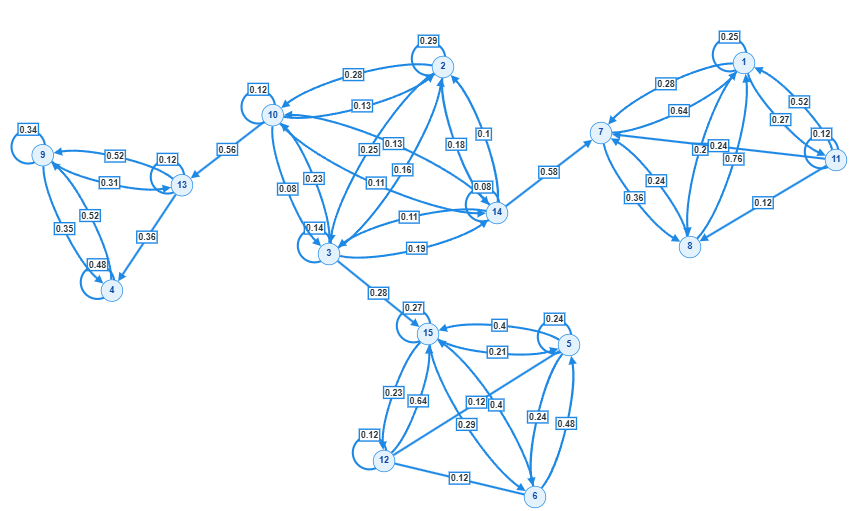

Для приведения к удобной нумерации нужно поменять строки и столбцы соответственно.
Порядок смены местами строк и столбцов:
14 и 1,
10 и 4,
14 и 5,
11 и 6,
15 и 9,
14 и 10.

Результат:
```
0.08 0.1  0.11 0.13 0    0    0.58 0    0    0    0    0    0    0    0
0.18 0.29 0.25 0.28 0    0    0    0    0    0    0    0    0    0    0
0.19 0.16 0.14 0.23 0    0    0    0    0.28 0    0    0    0    0    0
0.11 0.13 0.08 0.12 0    0    0    0    0    0    0    0    0.56 0    0
0    0    0    0    0.25 0.27 0.28 0.2  0    0    0    0    0    0    0
0    0    0    0    0.52 0.12 0.24 0.12 0    0    0    0    0    0    0
0    0    0    0    0.64 0    0    0.36 0    0    0    0    0    0    0
0    0    0    0    0.76 0    0.24 0    0    0    0    0    0    0    0
0    0    0    0    0    0    0    0    0.27 0.21 0.29 0.23 0    0    0
0    0    0    0    0    0    0    0    0.4  0.24 0.24 0.12 0    0    0
0    0    0    0    0    0    0    0    0.4  0.48 0    0.12 0    0    0
0    0    0    0    0    0    0    0    0.64 0.12 0.12 0.12 0    0    0
0    0    0    0    0    0    0    0    0    0    0    0    0.12 0.36 0.52
0    0    0    0    0    0    0    0    0    0    0    0    0    0.48 0.52
0    0    0    0    0    0    0    0    0    0    0    0    0.31 0.35 0.34
```



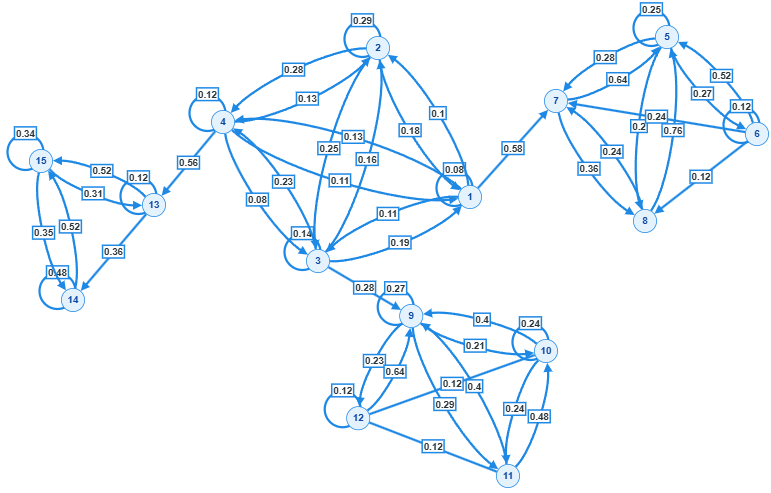

In [12]:
import numpy as np
import random as rd
import matplotlib.pyplot as plt
import matplotlib as mpl

np.set_printoptions(linewidth=200)

# Было
# P = np.array([
#     [0.25, 0.00, 0.00, 0.00, 0.00, 0.00, 0.28, 0.20, 0.00, 0.00, 0.27, 0.00, 0.00, 0.00, 0.00],
#     [0.00, 0.29, 0.25, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.28, 0.00, 0.00, 0.00, 0.18, 0.00],
#     [0.00, 0.16, 0.14, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.23, 0.00, 0.00, 0.00, 0.19, 0.28],
#     [0.00, 0.00, 0.00, 0.48, 0.00, 0.00, 0.00, 0.00, 0.52, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
#     [0.00, 0.00, 0.00, 0.00, 0.24, 0.24, 0.00, 0.00, 0.00, 0.00, 0.00, 0.12, 0.00, 0.00, 0.40],
#     [0.00, 0.00, 0.00, 0.00, 0.48, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.12, 0.00, 0.00, 0.40],
#     [0.64, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.36, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
#     [0.76, 0.00, 0.00, 0.00, 0.00, 0.00, 0.24, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
#     [0.00, 0.00, 0.00, 0.35, 0.00, 0.00, 0.00, 0.00, 0.34, 0.00, 0.00, 0.00, 0.31, 0.00, 0.00],
#     [0.00, 0.13, 0.08, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.12, 0.00, 0.00, 0.56, 0.11, 0.00],
#     [0.52, 0.00, 0.00, 0.00, 0.00, 0.00, 0.24, 0.12, 0.00, 0.00, 0.12, 0.00, 0.00, 0.00, 0.00],
#     [0.00, 0.00, 0.00, 0.00, 0.12, 0.12, 0.00, 0.00, 0.00, 0.00, 0.00, 0.12, 0.00, 0.00, 0.64],
#     [0.00, 0.00, 0.00, 0.36, 0.00, 0.00, 0.00, 0.00, 0.52, 0.00, 0.00, 0.00, 0.12, 0.00, 0.00],
#     [0.00, 0.10, 0.11, 0.00, 0.00, 0.00, 0.58, 0.00, 0.00, 0.13, 0.00, 0.00, 0.00, 0.08, 0.00],
#     [0.00, 0.00, 0.00, 0.00, 0.21, 0.29, 0.00, 0.00, 0.00, 0.00, 0.00, 0.23, 0.00, 0.00, 0.27]
# ])

P = np.array([
    [0.08, 0.1,  0.11, 0.13, 0,    0,    0.58, 0,    0,    0,    0,    0,    0,    0,    0], #    1
    [0.18, 0.29, 0.25, 0.28, 0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0], #    2
    [0.19, 0.16, 0.14, 0.23, 0,    0,    0,    0,    0.28, 0,    0,    0,    0,    0,    0], #    3
    [0.11, 0.13, 0.08, 0.12, 0,    0,    0,    0,    0,    0,    0,    0,    0.56, 0,    0], #    4
    [0,    0,    0,    0,    0.25, 0.27, 0.28, 0.2,  0,    0,    0,    0,    0,    0,    0], #    5
    [0,    0,    0,    0,    0.52, 0.12, 0.24, 0.12, 0,    0,    0,    0,    0,    0,    0], #    6
    [0,    0,    0,    0,    0.64, 0,    0,    0.36, 0,    0,    0,    0,    0,    0,    0], #    7
    [0,    0,    0,    0,    0.76, 0,    0.24, 0,    0,    0,    0,    0,    0,    0,    0], #    8
    [0,    0,    0,    0,    0,    0,    0,    0,    0.27, 0.21, 0.29, 0.23, 0,    0,    0], #    9
    [0,    0,    0,    0,    0,    0,    0,    0,    0.4,  0.24, 0.24, 0.12, 0,    0,    0], #    10
    [0,    0,    0,    0,    0,    0,    0,    0,    0.4,  0.48, 0,    0.12, 0,    0,    0], #    11
    [0,    0,    0,    0,    0,    0,    0,    0,    0.64, 0.12, 0.12, 0.12, 0,    0,    0], #    12
    [0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0.12, 0.36, 0.52], # 13
    [0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0.48, 0.52], # 14
    [0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0.31, 0.35, 0.34]  # 15
])

In [13]:
Pn_big = np.zeros((15,15))
P_classes = np.array([np.copy(P[:4,:4]), np.copy(P[4:8,4:8]), np.copy(P[8:12,8:12])] )

for i in range(1, 3):
  Pt = P_classes[i].T - np.eye(4)
  Pt[-1] = 1
  Pn = np.linalg.solve( Pt, np.array([[0.], [0.], [0.], [1.]]) )
  PnT = Pn.T
  Pn_big[i*4:(i+1)*4, i*4:(i+1)*4] = Pn.T

Pt = np.copy(P[12:,12:]).T - np.eye(3)
Pt[-1] = 1
Pn = np.linalg.solve( Pt, np.array([ [0.], [0.], [1.]]) )
Pn_big[12:,12:] = Pn.T

# print(np.round(Pn_big, 1))



Pn_smol = np.zeros((7, 7))
Pn_smol[:4, :4] = P[:4, :4]
Pn_smol[0, 4] = 0.58
Pn_smol[2, 5] = 0.28
Pn_smol[3, 6] = 0.56
Pn_smol[4:7, 4:7] = np.eye(3)
print(np.round(Pn_smol, 5)) # матрица для классов

prev_elem = 0
curr_elem = 1
res = np.copy(Pn_smol)
while((curr_elem - prev_elem) > 0.1e-9):
  prev_elem = res[0, 4]
  res = res @ Pn_smol
  curr_elem = res[0, 4]

res = res[:4, 4:]
print("Предельные вероятности для перехода в существенные классы \n", np.round(res, 3) )

# print(np.round(Pn_big, 2))
for i in range(2):
    Pn_big[0:4, (i+1)*4:(i+2)*4] = Pn_big[(i+1)*4:(i+2)*4, (i+1)*4:(i+2)*4] * res[:, i:i+1]
    # print(Pn_big[(i+1)*4:(i+2)*4, (i+1)*4:(i+2)*4], res[:, i:i+1])

Pn_big[0:3, 12:] = Pn_big[12:, 12:] * res[:3, 2:]
Pn_big[3:4, 12:] = Pn_big[12:13, 12:] * res[3:, 2:]
print(sum(Pn_big[3]))

print("Предельные вероятности для каждого исходного состояния\n", np.round(Pn_big, 2))

print("Предельные вероятности для равновероятных несущественных\n", np.round(np.mean(Pn_big[:4, :], axis=0 ), 1))

[[0.08 0.1  0.11 0.13 0.58 0.   0.  ]
 [0.18 0.29 0.25 0.28 0.   0.   0.  ]
 [0.19 0.16 0.14 0.23 0.   0.28 0.  ]
 [0.11 0.13 0.08 0.12 0.   0.   0.56]
 [0.   0.   0.   0.   1.   0.   0.  ]
 [0.   0.   0.   0.   0.   1.   0.  ]
 [0.   0.   0.   0.   0.   0.   1.  ]]
Предельные вероятности для перехода в существенные классы 
 [[0.723 0.079 0.198]
 [0.343 0.189 0.468]
 [0.268 0.398 0.334]
 [0.165 0.074 0.761]]
0.9999999996008706
Предельные вероятности для каждого исходного состояния
 [[0.   0.   0.   0.   0.34 0.1  0.15 0.13 0.03 0.02 0.02 0.01 0.03 0.08 0.09]
 [0.   0.   0.   0.   0.16 0.05 0.07 0.06 0.07 0.05 0.04 0.03 0.07 0.19 0.21]
 [0.   0.   0.   0.   0.12 0.04 0.06 0.05 0.15 0.1  0.08 0.06 0.05 0.14 0.15]
 [0.   0.   0.   0.   0.08 0.02 0.03 0.03 0.03 0.02 0.01 0.01 0.12 0.31 0.34]
 [0.   0.   0.   0.   0.46 0.14 0.21 0.18 0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.46 0.14 0.21 0.18 0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.46 0.14 0.21 0.18 0. 

/tmp/ipykernel_2176/2787941442.py:22: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "x" (-> marker='x'). The keyword argument will take precedence.
  ax.plot(range(100), S_j, 'x', ls='-', color=colors[k], linewidth=1.0, marker='x')


Числа вхождений
 [[ 1.  0.  0. ...  0.  0.  0.]
 [ 1.  0.  0. ... 15. 42. 41.]
 [ 1.  1.  0. ... 17. 38. 42.]
 ...
 [ 0.  0.  0. ... 18. 43. 39.]
 [ 0.  0.  0. ... 13. 43. 44.]
 [ 0.  0.  0. ... 13. 42. 45.]]


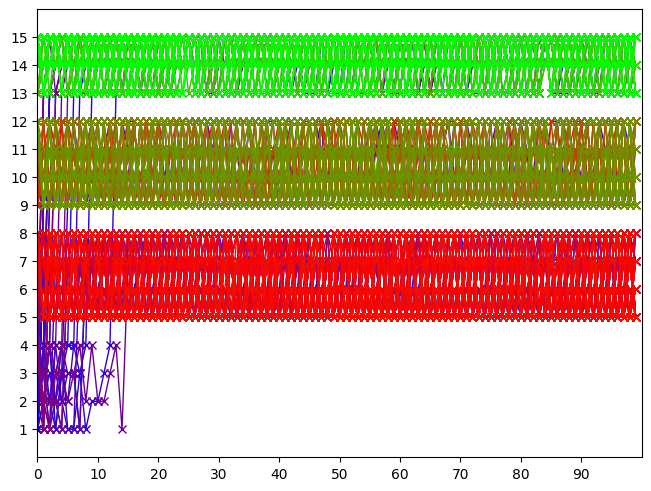

In [14]:
fig, ax = plt.subplots(layout='constrained')
cmap = mpl.colormaps['brg']
colors = cmap(np.linspace(0, 1, 151))

S_n = np.ones((150, 15))                  # Массивы вхождений экспериментов
k = 0
for st in range(1, 16):
  for n in range(10):
    S_i = st
    S = np.zeros(15)  # Массив чисел вхождений для n-нного эксперимента
    S_j = np.zeros(100)

    S_j[0] = S_i
    S[S_i - 1] += 1
    for j in range(1, 100):
      S_i = rd.choices(range(1, 16), weights=P[S_i - 1], k=1)[0]
      S_j[j] = S_i
      S[S_i - 1] += 1
    S_n[k] = S
    k+=1
    if (True):
      ax.plot(range(100), S_j, 'x', ls='-', color=colors[k], linewidth=1.0, marker='x')
      ax.set(xlim=(0, 100), xticks=np.arange(0, 100, 10), ylim=(0, 16), yticks=np.arange(1, 16))


print("Числа вхождений\n", S_n )
# print("Таблица для сравнений\n", S_n[:]/100)
# print("Предельные вероятности: ", *Pn.T)

# print("Выборочные средние оценки: ", np.mean(S_n[:]/100, axis=0))

# print("Исправленные оценки среднеквадратичных отклонений")
# for i in range(5):
#     print( ( (S_n[:, i]/100 - np.mean(S_n[:]/100, axis=0)[i]) ** 2).sum() / 99)

plt.show()